


##Завдання 1


In [37]:
!pip -q install kagglehub

In [38]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

plt.rcParams['figure.figsize'] = (10, 6)

In [39]:
path1 = kagglehub.dataset_download('nelgiriyewithana/global-youtube-statistics-2023')
print('Path to dataset files:', path1)

Using Colab cache for faster access to the 'global-youtube-statistics-2023' dataset.
Path to dataset files: /kaggle/input/global-youtube-statistics-2023


In [40]:
csv_files = glob.glob(os.path.join(path1, '*.csv'))
print('Знайдені CSV-файли:', csv_files)

youtube_file = csv_files[0]

encodings = ['utf-8', 'latin1', 'ISO-8859-1', 'cp1252']
df1 = None

for enc in encodings:
    try:
        df1 = pd.read_csv(youtube_file, encoding=enc)
        print(f'Файл успішно прочитано з кодуванням: {enc}')
        break
    except Exception as e:
        print(f'Не підійшло кодування {enc}: {e}')

if df1 is None:
    raise ValueError('Не вдалося прочитати CSV з жодним із кодувань.')

print('Файл завантажено:', youtube_file)
print('Розмір датасету:', df1.shape)

Знайдені CSV-файли: ['/kaggle/input/global-youtube-statistics-2023/Global YouTube Statistics.csv']
Не підійшло кодування utf-8: 'utf-8' codec can't decode byte 0xfd in position 0: invalid start byte
Файл успішно прочитано з кодуванням: latin1
Файл завантажено: /kaggle/input/global-youtube-statistics-2023/Global YouTube Statistics.csv
Розмір датасету: (995, 28)


In [41]:
print('Перші 5 рядків датасету:')
df1.head()

Перші 5 рядків датасету:


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [42]:
print('Розмір датасету:', df1.shape)

print('\nКількість пропусків по стовпцях:')
print(df1.isnull().sum())

print('\nКількість дублікатів:')
print(df1.duplicated().sum())

print('\nНазви стовпців:')
print(df1.columns.tolist())

Розмір датасету: (995, 28)

Кількість пропусків по стовпцях:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5

In [43]:
df1_fixed = df1.copy()

for col in df1_fixed.columns:
    cleaned = pd.to_numeric(
        df1_fixed[col].astype(str).str.replace(',', '', regex=False).str.strip(),
        errors='coerce'
    )
    if cleaned.notna().sum() > len(df1_fixed) * 0.5:
        df1_fixed[col] = cleaned.astype(float)

numeric_cols = df1_fixed.select_dtypes(include=['number']).columns

for col in numeric_cols:
    df1_fixed[col] = df1_fixed[col].fillna(df1_fixed[col].mean())

print('Пропуски після заповнення:')
print(df1_fixed.isnull().sum())

Пропуски після заповнення:
rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             0
country_rank                                 0
channel_type_rank                            0
video_views_for_the_last_30_days             0
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days                 0
created_year                                 0
created_month                    

In [44]:
if 'Country' in df1_fixed.columns:
    unique_countries = df1_fixed['Country'].nunique()
    print('Кількість унікальних країн у колонці Country:', unique_countries)
else:
    print('Колонку Country не знайдено')

Кількість унікальних країн у колонці Country: 49


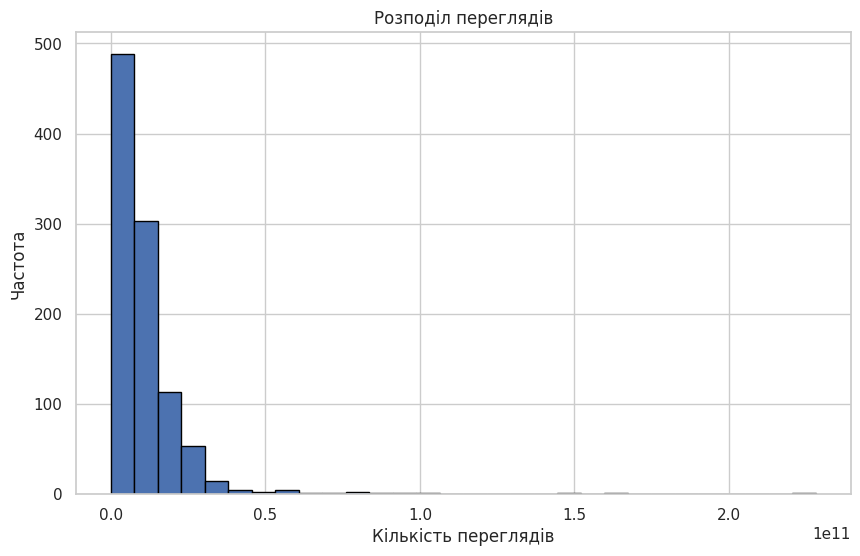

In [45]:
views_col = 'video views'

if views_col in df1_fixed.columns:
    df1_fixed[views_col].plot(kind='hist', bins=30, edgecolor='black')
    plt.title('Розподіл переглядів')
    plt.xlabel('Кількість переглядів')
    plt.ylabel('Частота')
    plt.show()
else:
    print(f'Колонку {views_col} не знайдено')

In [46]:
views_col = 'video views'

if views_col in df1_fixed.columns:
    print('Максимальна кількість переглядів:', df1_fixed[views_col].max())
    print('Мінімальна кількість переглядів:', df1_fixed[views_col].min())
    print('Середня кількість переглядів:', df1_fixed[views_col].mean())
else:
    print(f'Колонку {views_col} не знайдено')

Максимальна кількість переглядів: 228000000000.0
Мінімальна кількість переглядів: 0.0
Середня кількість переглядів: 11039537052.03819


In [47]:
if 'Country' in df1_fixed.columns and 'uploads' in df1_fixed.columns:
    country_uploads = df1_fixed.groupby('Country')['uploads'].sum().sort_values(ascending=False)
    print('Країна, де найбільше відео було завантажено на YouTube:')
    print(country_uploads.head(1))
else:
    print('Колонки Country або uploads не знайдено')

Країна, де найбільше відео було завантажено на YouTube:
Country
India    3728212.0
Name: uploads, dtype: float64


In [48]:
if 'uploads' in df1_fixed.columns and 'Youtuber' in df1_fixed.columns:
    max_upload_row = df1_fixed.loc[df1_fixed['uploads'].idxmax()]
    min_upload_row = df1_fixed.loc[df1_fixed['uploads'].idxmin()]

    print('Канал з максимальною кількістю uploads:')
    print(max_upload_row['Youtuber'])

    print('\nКанал з мінімальною кількістю uploads:')
    print(min_upload_row['Youtuber'])
else:
    print('Колонки uploads або Youtuber не знайдено')

Канал з максимальною кількістю uploads:
ABP NEWS

Канал з мінімальною кількістю uploads:
Music




## Завдання 2


In [49]:
!pip -q install kagglehub

In [50]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [51]:
path2 = kagglehub.dataset_download('iamsouravbanerjee/customer-shopping-trends-dataset')
print('Шлях до файлів датасету:', path2)

Using Colab cache for faster access to the 'customer-shopping-trends-dataset' dataset.
Шлях до файлів датасету: /kaggle/input/customer-shopping-trends-dataset


In [52]:
csv_files = glob.glob(os.path.join(path2, '*.csv'))
print('Знайдені CSV-файли:', csv_files)

shopping_file = None
for f in csv_files:
    if 'shopping_trends' in os.path.basename(f).lower():
        shopping_file = f
        break

if shopping_file is None and len(csv_files) > 0:
    shopping_file = csv_files[0]

if shopping_file is None:
    raise ValueError('CSV-файл не знайдено.')

df2 = pd.read_csv(shopping_file)

print('Файл завантажено:', shopping_file)
print('Розмір таблиці:', df2.shape)

Знайдені CSV-файли: ['/kaggle/input/customer-shopping-trends-dataset/shopping_trends.csv', '/kaggle/input/customer-shopping-trends-dataset/shopping_trends_updated.csv']
Файл завантажено: /kaggle/input/customer-shopping-trends-dataset/shopping_trends.csv
Розмір таблиці: (3900, 19)


In [53]:
print('Розмір таблиці:')
print(df2.shape)

print('\nКількість пропусків по стовпцях:')
print(df2.isnull().sum())

print('\nТипи стовпців:')
print(df2.dtypes)

Розмір таблиці:
(3900, 19)

Кількість пропусків по стовпцях:
Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64

Типи стовпців:
Customer ID                   int64
Age                           int64
Gender                       object
Item Purchased               object
Category                     object
Purchase Amount (USD)         int64
Location                     object
Size                         object
Color                        object
Season          

In [54]:
df2.columns = df2.columns.str.lower().str.replace(' ', '_')

print('Нові назви стовпців:')
print(df2.columns.tolist())

Нові назви стовпців:
['customer_id', 'age', 'gender', 'item_purchased', 'category', 'purchase_amount_(usd)', 'location', 'size', 'color', 'season', 'review_rating', 'subscription_status', 'payment_method', 'shipping_type', 'discount_applied', 'promo_code_used', 'previous_purchases', 'preferred_payment_method', 'frequency_of_purchases']


In [55]:
purchase_col = None
for col in df2.columns:
    if 'purchase_amount' in col:
        purchase_col = col
        break

print('Стовпець із сумою покупки:', purchase_col)

Стовпець із сумою покупки: purchase_amount_(usd)


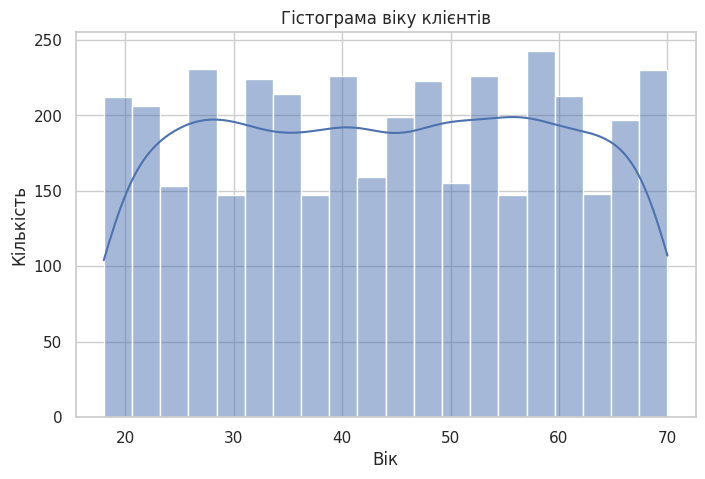

In [56]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df2, x='age', bins=20, kde=True)
plt.title('Гістограма віку клієнтів')
plt.xlabel('Вік')
plt.ylabel('Кількість')
plt.show()

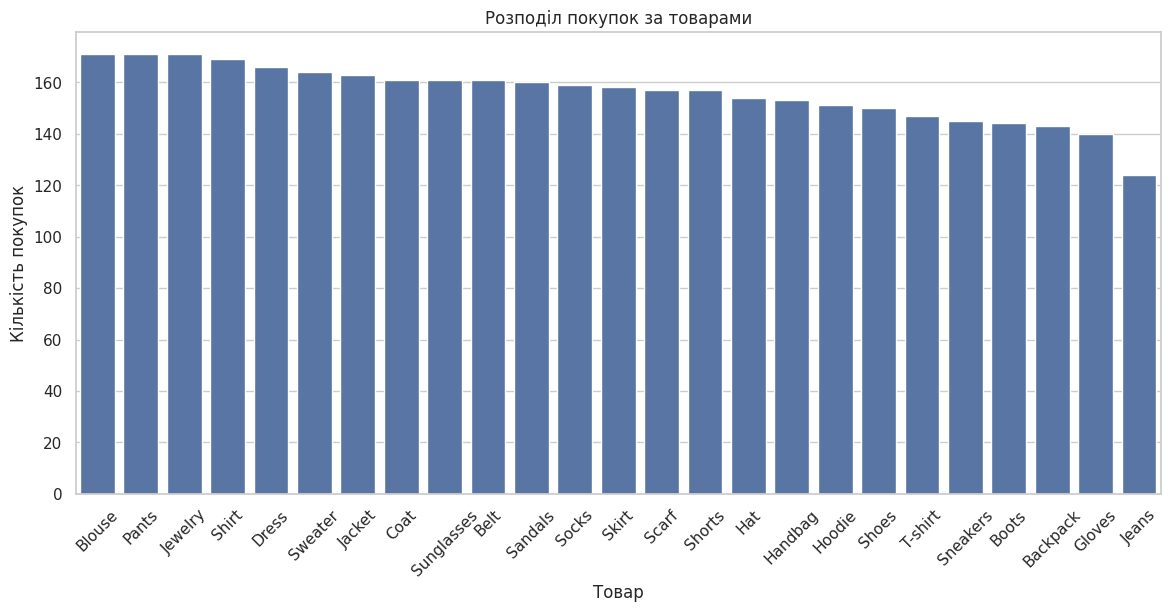

In [57]:
plt.figure(figsize=(14, 6))
order_items = df2['item_purchased'].value_counts().index
sns.countplot(data=df2, x='item_purchased', order=order_items)
plt.title('Розподіл покупок за товарами')
plt.xlabel('Товар')
plt.ylabel('Кількість покупок')
plt.xticks(rotation=45)
plt.show()

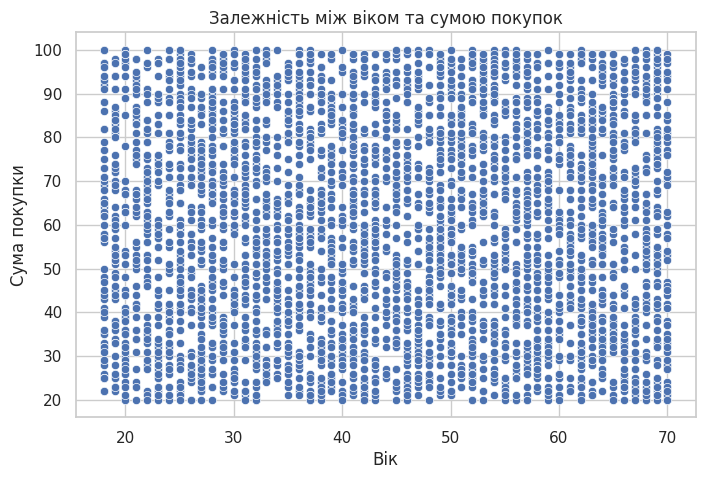

In [58]:
if purchase_col is not None:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df2, x='age', y=purchase_col)
    plt.title('Залежність між віком та сумою покупок')
    plt.xlabel('Вік')
    plt.ylabel('Сума покупки')
    plt.show()
else:
    print('Стовпець із сумою покупки не знайдено.')

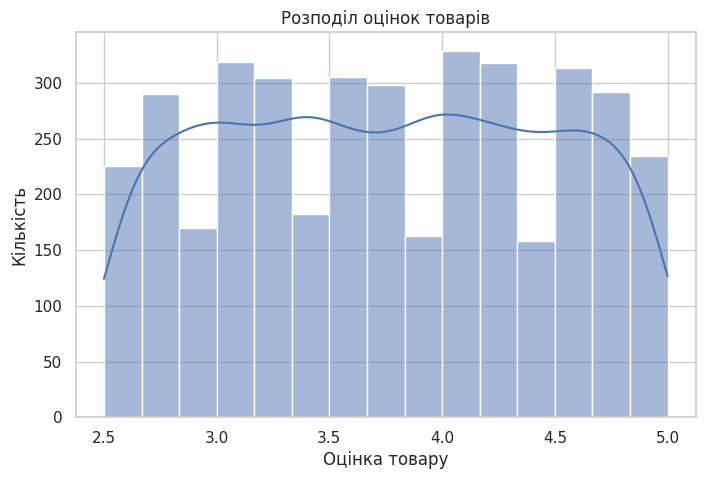

In [59]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df2, x='review_rating', bins=15, kde=True)
plt.title('Розподіл оцінок товарів')
plt.xlabel('Оцінка товару')
plt.ylabel('Кількість')
plt.show()

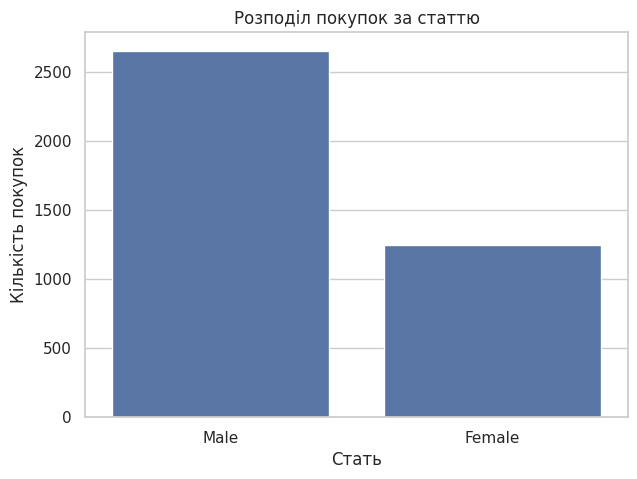

In [60]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df2, x='gender')
plt.title('Розподіл покупок за статтю')
plt.xlabel('Стать')
plt.ylabel('Кількість покупок')
plt.show()

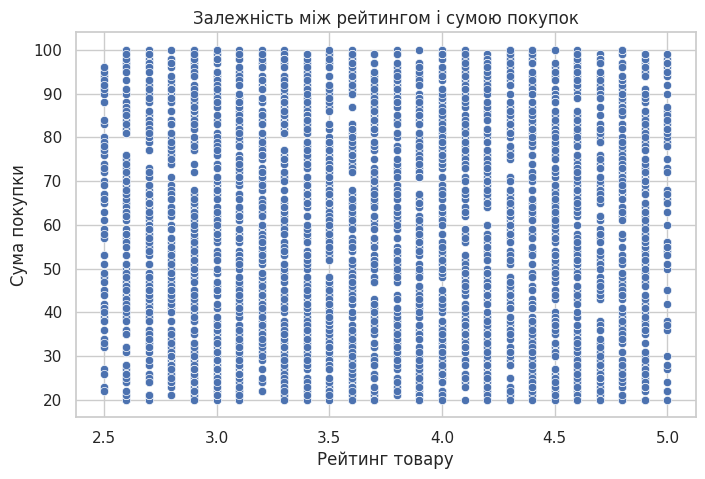

In [61]:
if purchase_col is not None:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df2, x='review_rating', y=purchase_col)
    plt.title('Залежність між рейтингом і сумою покупок')
    plt.xlabel('Рейтинг товару')
    plt.ylabel('Сума покупки')
    plt.show()
else:
    print('Стовпець із сумою покупки не знайдено.')



## Завдання 3


### 1. Встановлення потрібних бібліотек

In [62]:
!pip -q install altair vega_datasets plotly scikit-learn

### 2. Імпорт бібліотек

In [63]:
import altair as alt
import plotly.express as px
import pandas as pd

from vega_datasets import data
from sklearn.datasets import load_iris

alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [64]:
wheat = data.wheat()
wheat.head()

,year,wheat,wages
0,1565,41.0,5.00
1,1570,45.0,5.05
2,1575,42.0,5.08
3,1580,49.0,5.12
4,1585,41.5,5.15


In [65]:
bars = alt.Chart(wheat).mark_bar().encode(
    x=alt.X('wheat:Q', title='Врожайність пшениці'),
    y=alt.Y('year:O', title='Рік')
)

text = alt.Chart(wheat).mark_text(
    align='left',
    baseline='middle',
    dx=4
).encode(
    x='wheat:Q',
    y='year:O',
    text=alt.Text('wheat:Q', format='.1f')
)

chart_wheat = (bars + text).properties(
    title='Горизонтальна діаграма врожайності пшениці'
)

chart_wheat

alt.LayerChart(...)

In [66]:
iowa = data.iowa_electricity()
iowa.head()

,year,source,net_generation
0,2001-01-01,Fossil Fuels,35361
1,2002-01-01,Fossil Fuels,35991
2,2003-01-01,Fossil Fuels,36234
3,2004-01-01,Fossil Fuels,36205
4,2005-01-01,Fossil Fuels,36883


In [67]:
sources = iowa['source'].unique().tolist()

layers = []
for src in sources:
    layer = alt.Chart(iowa).transform_filter(
        alt.datum.source == src
    ).mark_bar(opacity=0.7).encode(
        x=alt.X('year:T', title='Рік'),
        y=alt.Y('net_generation:Q', title='Чисте виробництво електроенергії'),
        color=alt.Color('source:N', title='Джерело енергії')
    )
    layers.append(layer)

chart_iowa = alt.layer(*layers).properties(
    title='Багатошарова діаграма виробництва електроенергії в штаті Айова'
)

chart_iowa

alt.LayerChart(...)

In [68]:
iris_raw = load_iris(as_frame=True)
iris_df = iris_raw.frame.copy()
iris_df['species'] = iris_df['target'].map(dict(enumerate(iris_raw.target_names)))

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [69]:
fig = px.scatter(
    iris_df,
    x='sepal width (cm)',
    y='sepal length (cm)',
    size='petal length (cm)',
    color='species',
    hover_data=['petal width (cm)'],
    title='Scatter Plot для набору даних Iris'
)

fig.update_layout(
    xaxis_title='Ширина чашолистка (sepal width)',
    yaxis_title='Довжина чашолистка (sepal length)',
    legend_title='Вид (species)'
)

fig.show()